In [14]:
!pip install tensorflow -q

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [3]:
# Simple neural network structure demo
model_demo = Sequential()
model_demo.add(Dense(8, activation='relu', input_shape=(4,)))
model_demo.add(Dense(4, activation='relu'))
model_demo.add(Dense(1))

model_demo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Tokenize JurisAI court texts
court_texts = [
    "the court delivered judgment in favor of the plaintiff",
    "the defendant filed an appeal against the ruling",
    "the judge presided over the case in the high court",
    "the lawyer presented evidence to support the claim",
    "the plaintiff sought compensation for damages",
    "the defendant denied the allegations in court",
    "the magistrate issued a ruling on the bail application",
    "the court of appeal reviewed the judgment",
    "the witness gave testimony before the court",
    "the prosecution presented evidence against the accused",
]

tokenizer = Tokenizer()
tokenizer.fit_on_texts(court_texts)

print("WORD INDEX — JurisAI Court Vocabulary")
print("=" * 45)
print(tokenizer.word_index)
print(f"\nTotal unique words: {len(tokenizer.word_index)}")

WORD INDEX — JurisAI Court Vocabulary
{'the': 1, 'court': 2, 'in': 3, 'judgment': 4, 'of': 5, 'plaintiff': 6, 'defendant': 7, 'appeal': 8, 'against': 9, 'ruling': 10, 'presented': 11, 'evidence': 12, 'delivered': 13, 'favor': 14, 'filed': 15, 'an': 16, 'judge': 17, 'presided': 18, 'over': 19, 'case': 20, 'high': 21, 'lawyer': 22, 'to': 23, 'support': 24, 'claim': 25, 'sought': 26, 'compensation': 27, 'for': 28, 'damages': 29, 'denied': 30, 'allegations': 31, 'magistrate': 32, 'issued': 33, 'a': 34, 'on': 35, 'bail': 36, 'application': 37, 'reviewed': 38, 'witness': 39, 'gave': 40, 'testimony': 41, 'before': 42, 'prosecution': 43, 'accused': 44}

Total unique words: 44


In [5]:
sequences = tokenizer.texts_to_sequences(court_texts)

print("TEXT TO SEQUENCES")
print("=" * 45)
for i, (text, seq) in enumerate(zip(court_texts, sequences)):
    print(f"\nText {i+1}: {text}")
    print(f"Sequence: {seq}")

TEXT TO SEQUENCES

Text 1: the court delivered judgment in favor of the plaintiff
Sequence: [1, 2, 13, 4, 3, 14, 5, 1, 6]

Text 2: the defendant filed an appeal against the ruling
Sequence: [1, 7, 15, 16, 8, 9, 1, 10]

Text 3: the judge presided over the case in the high court
Sequence: [1, 17, 18, 19, 1, 20, 3, 1, 21, 2]

Text 4: the lawyer presented evidence to support the claim
Sequence: [1, 22, 11, 12, 23, 24, 1, 25]

Text 5: the plaintiff sought compensation for damages
Sequence: [1, 6, 26, 27, 28, 29]

Text 6: the defendant denied the allegations in court
Sequence: [1, 7, 30, 1, 31, 3, 2]

Text 7: the magistrate issued a ruling on the bail application
Sequence: [1, 32, 33, 34, 10, 35, 1, 36, 37]

Text 8: the court of appeal reviewed the judgment
Sequence: [1, 2, 5, 8, 38, 1, 4]

Text 9: the witness gave testimony before the court
Sequence: [1, 39, 40, 41, 42, 1, 2]

Text 10: the prosecution presented evidence against the accused
Sequence: [1, 43, 11, 12, 9, 1, 44]


In [6]:
# Use the simple demo model from Cell 3 to show prediction output
sample = np.array([[1, 2, 3, 4]])
prediction = model_demo.predict(sample)

print("Sample input:", sample)
print("Prediction output:", prediction)
print("\n(Note: model_demo has no trained meaning yet — this just shows the output shape)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Sample input: [[1 2 3 4]]
Prediction output: [[-0.44302535]]

(Note: model_demo has no trained meaning yet — this just shows the output shape)


In [7]:
print("""
COMPARISON: N-GRAM vs NEURAL LANGUAGE MODEL
============================================

Feature              | N-Gram Model            | Neural Language Model
---------------------|-------------------------|-------------------------
Context Understanding| Limited (fixed window)  | Long-range context
Memory Usage         | Very high (grows fast)  | Compact learned weights
Semantic Learning    | None                    | Learns word meaning
Prediction Accuracy  | Low on unseen text      | High generalization
""")


COMPARISON: N-GRAM vs NEURAL LANGUAGE MODEL

Feature              | N-Gram Model            | Neural Language Model
---------------------|-------------------------|-------------------------
Context Understanding| Limited (fixed window)  | Long-range context
Memory Usage         | Very high (grows fast)  | Compact learned weights
Semantic Learning    | None                    | Learns word meaning
Prediction Accuracy  | Low on unseen text      | High generalization



In [8]:
#  STEP 1: Dataset
vocab_size = len(tokenizer.word_index) + 1

#  STEP 2: Build n-gram input sequences
input_sequences = []
for seq in sequences:
    for i in range(1, len(seq)):
        input_sequences.append(seq[:i+1])

max_len = max(len(s) for s in input_sequences)
padded = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = padded[:, :-1]
y = to_categorical(padded[:, -1], num_classes=vocab_size)

print(f"Training samples: {X.shape[0]}")
print(f"Sequence length:  {X.shape[1]}")
print(f"Vocabulary size:  {vocab_size}")

Training samples: 68
Sequence length:  9
Vocabulary size:  45


In [9]:
#  STEP 3: Build model
model = Sequential([
    Embedding(vocab_size, 10, input_length=max_len - 1),
    LSTM(64),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

#  STEP 4: Train
print("\nTraining...")
history = model.fit(X, y, epochs=200, verbose=0)
print(f"Final training accuracy: {history.history['accuracy'][-1]*100:.1f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training...
Final training accuracy: 63.2%


In [10]:
def predict_next_word(seed_text, top_n=3):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
    predictions = model.predict(token_list, verbose=0)[0]
    top_indices = np.argsort(predictions)[-top_n:][::-1]

    results = []
    for idx in top_indices:
        for word, index in tokenizer.word_index.items():
            if index == idx:
                results.append((word, round(float(predictions[idx]) * 100, 2)))
    return results

# Test predictions on court sentence fragments
print("NEXT WORD PREDICTIONS — JurisAI")
print("=" * 45)

seeds = [
    "the court",
    "the judge",
    "the defendant",
    "the lawyer presented",
    "the witness gave",
]

for seed in seeds:
    preds = predict_next_word(seed)
    print(f"\nInput: '{seed}'")
    for word, conf in preds:
        print(f"   -> {word} ({conf}% confidence)")

NEXT WORD PREDICTIONS — JurisAI

Input: 'the court'
   -> judgment (11.81% confidence)
   -> delivered (10.38% confidence)
   -> court (8.46% confidence)

Input: 'the judge'
   -> presented (10.51% confidence)
   -> presided (7.52% confidence)
   -> court (6.89% confidence)

Input: 'the defendant'
   -> court (7.74% confidence)
   -> filed (7.1% confidence)
   -> delivered (6.99% confidence)

Input: 'the lawyer presented'
   -> evidence (21.84% confidence)
   -> testimony (10.79% confidence)
   -> a (9.65% confidence)

Input: 'the witness gave'
   -> evidence (15.75% confidence)
   -> testimony (11.8% confidence)
   -> the (9.06% confidence)


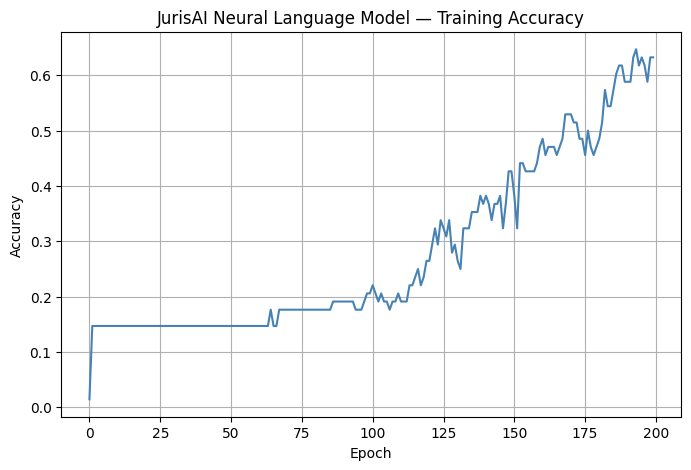

Saved training_accuracy.png


In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], color='steelblue')
plt.title("JurisAI Neural Language Model — Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.savefig("training_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved training_accuracy.png")

In [12]:
# Accepts new text input, tokenizes, displays indices and sequences
new_texts = [
    "the court reviewed the evidence",
    "the judge delivered the ruling",
]

print("TENSORFLOW NLP EXERCISE")
print("=" * 45)

for text in new_texts:
    seq = tokenizer.texts_to_sequences([text])[0]
    print(f"\nInput text : {text}")
    print(f"Word index : ", end="")
    for word in text.split():
        idx = tokenizer.word_index.get(word, "?")
        print(f"{word}={idx}", end=" ")
    print(f"\nSequence   : {seq}")

TENSORFLOW NLP EXERCISE

Input text : the court reviewed the evidence
Word index : the=1 court=2 reviewed=38 the=1 evidence=12 
Sequence   : [1, 2, 38, 1, 12]

Input text : the judge delivered the ruling
Word index : the=1 judge=17 delivered=13 the=1 ruling=10 
Sequence   : [1, 17, 13, 1, 10]


In [13]:
import json

with open("court_texts.json", "w") as f:
    json.dump(court_texts, f, indent=2)

print("Saved court_texts.json")

Saved court_texts.json
